In [2]:
import pandas as pd

url = "/Users/varaprasadbolisetty/Desktop/AI-Testing/AI-Roadmap/Week1/titanic.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [3]:
# 1. Handle Missing Values

# Fill Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with most common value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin (too many missing values)
df = df.drop(columns=["Cabin"])

In [4]:
# 2. Convert Data Types

df["Survived"] = df["Survived"].astype(int)
df["Pclass"] = df["Pclass"].astype("category")

In [5]:
# 3. Remove Duplicates

df = df.drop_duplicates()

In [6]:
df["Survived"].mean()

np.float64(0.3838383838383838)

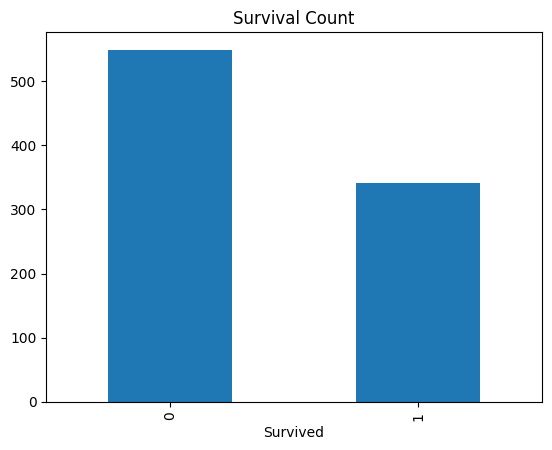

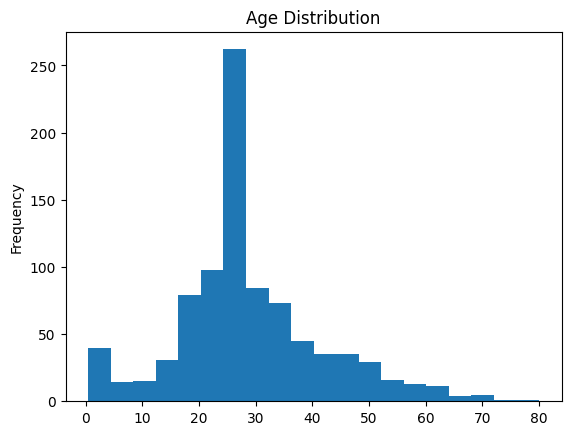

In [7]:
# Step 4: Simple Visualizations
import matplotlib.pyplot as plt

# Survival count
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.show()

# Age histogram
df["Age"].plot(kind="hist", bins=20)
plt.title("Age Distribution")
plt.show()

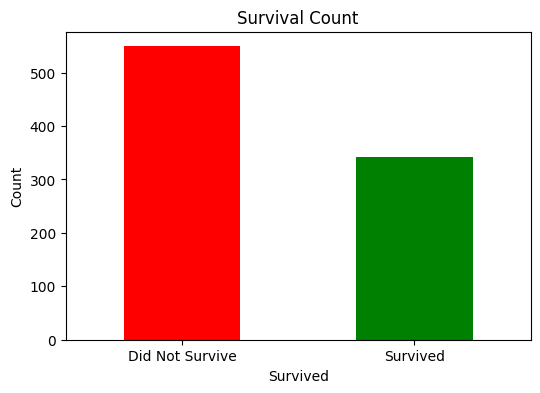

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df["Survived"].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Survival Count")
plt.xticks([0, 1], ["Did Not Survive", "Survived"], rotation=0)
plt.ylabel("Count")
plt.show()

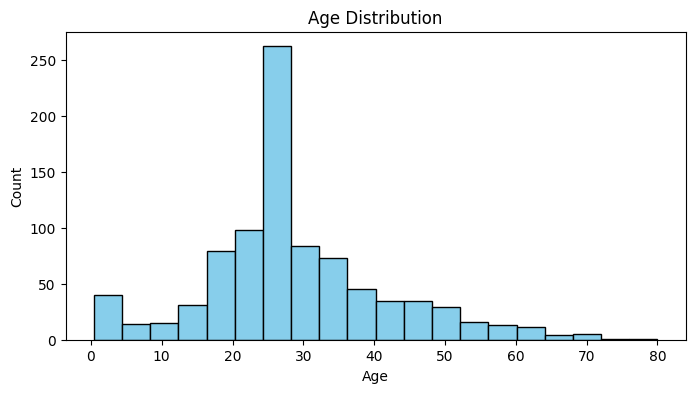

In [15]:
plt.figure(figsize=(8,4))
plt.hist(df["Age"], bins=20, color="skyblue", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

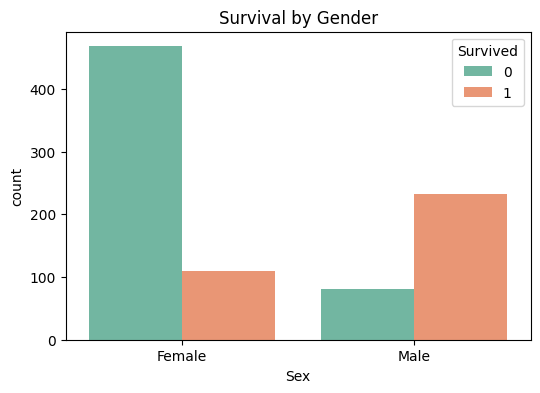

In [16]:
# Seaborn — Statistical & Beautiful Plots

import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df, palette="Set2")
plt.xticks([0, 1], ["Female", "Male"])
plt.title("Survival by Gender")
plt.show()

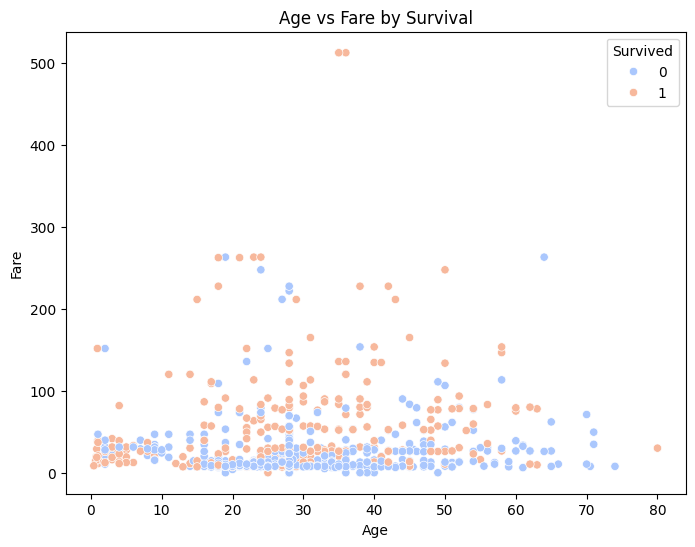

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, palette="coolwarm")
plt.title("Age vs Fare by Survival")
plt.show()

In [20]:
pip install plotly

     |████████████████████████████████| 9.9 MB 6.4 MB/s eta 0:00:01
     |████████████████████████████████| 444 kB 35.5 MB/s eta 0:00:01
You should consider upgrading via the '/Users/varaprasadbolisetty/Desktop/AI-Testing/AI-Roadmap/venv_week1/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [21]:
# Plotly — Interactive Visualizations
# Plotly is for interactive plots, useful in dashboards or AI notebooks where you want:
# Zoom, pan, hover info
# Clickable legends
# Interactive dashboards

import plotly.express as px

fig = px.histogram(
    df,
    x="Sex",
    color="Survived",
    barmode="group",
    labels={"Sex": "Gender", "Survived": "Survival"},
    color_discrete_map={0: "red", 1: "green"},
    title="Interactive Survival by Gender",
)
fig.show()

In [22]:
fig = px.scatter(
    df,
    x="Age",
    y="Fare",
    color="Survived",
    labels={"Survived": "Survival"},
    title="Interactive Age vs Fare Scatter",
)
fig.show()

In [ ]:
| Goal / Insight               | Best Plot             | Library              | Minimal Example / Concept                                                                                              |
| ---------------------------- | --------------------- | -------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| Count of survivors           | Bar Chart / Countplot | Matplotlib / Seaborn | `df['Survived'].value_counts().plot(kind='bar')`<br>`sns.countplot(x='Survived', data=df)`                             |
| Survival by gender           | Grouped Bar           | Seaborn / Plotly     | `sns.countplot(x='Sex', hue='Survived', data=df)`<br>`px.histogram(df, x='Sex', color='Survived', barmode='group')`    |
| Survival by class            | Grouped Bar           | Seaborn              | `sns.countplot(x='Pclass', hue='Survived', data=df)`                                                                   |
| Age distribution             | Histogram             | Matplotlib / Seaborn | `plt.hist(df['Age'], bins=20)`<br>`sns.histplot(df['Age'], kde=True)`                                                  |
| Age vs Fare                  | Scatter               | Seaborn / Plotly     | `sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)`<br>`px.scatter(df, x='Age', y='Fare', color='Survived')` |
| Correlation between features | Heatmap               | Seaborn              | `sns.heatmap(df.corr(), annot=True)`                                                                                   |
| Feature importance (ML)      | Bar / Horizontal Bar  | Matplotlib / Seaborn | `plt.barh(features, importances)`                                                                                      |
| Interactive dashboards       | Any of above          | Plotly               | Hover, zoom, filter by class/gender                                                                                    |
